In [4]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Crime_Data_from_2020_to_Present.csv')

# Fill missing values
df['Weapon Used Cd'] = df['Weapon Used Cd'].fillna('No Weapon used')
df['Weapon Desc'] = df['Weapon Desc'].fillna('No weapon used')

# Save cleaned data if needed
df.to_csv("cleaned_crime_data.csv", index=False)
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], format="%m/%d/%Y %I:%M:%S %p", errors='coerce')

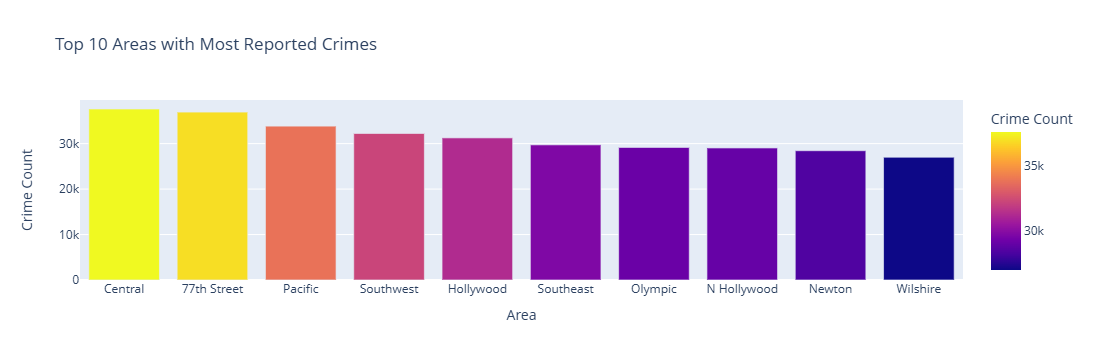

In [6]:
# --- 1. Most Common Crimes by Area ---
crime_area = df['AREA NAME'].value_counts().nlargest(10).reset_index()
crime_area.columns = ['Area', 'Crime Count']
fig1 = px.bar(crime_area, x='Area', y='Crime Count', color='Crime Count',
              title='Top 10 Areas with Most Reported Crimes')
fig1.show()

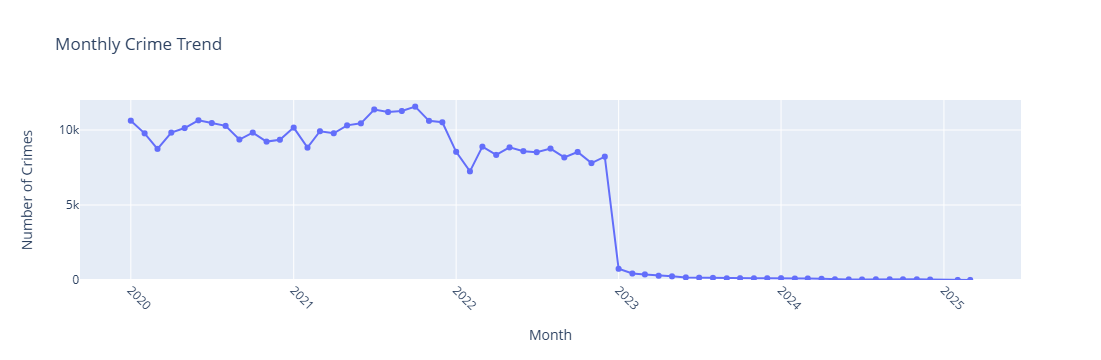

In [9]:
# --- 2. Crime Trend Over Time ---
# Fix: Convert to string after to_period
df['Month'] = df['Date Rptd'].dt.to_period('M').astype(str)
monthly_trend = df.groupby('Month').size().reset_index(name='Crime Count')
fig2 = px.line(monthly_trend, x='Month', y='Crime Count', markers=True,
               title='Monthly Crime Trend',
               labels={'Month': 'Month', 'Crime Count': 'Number of Crimes'})
fig2.update_layout(yaxis_range=[0,12000], xaxis_tickangle=45)
fig2.show()

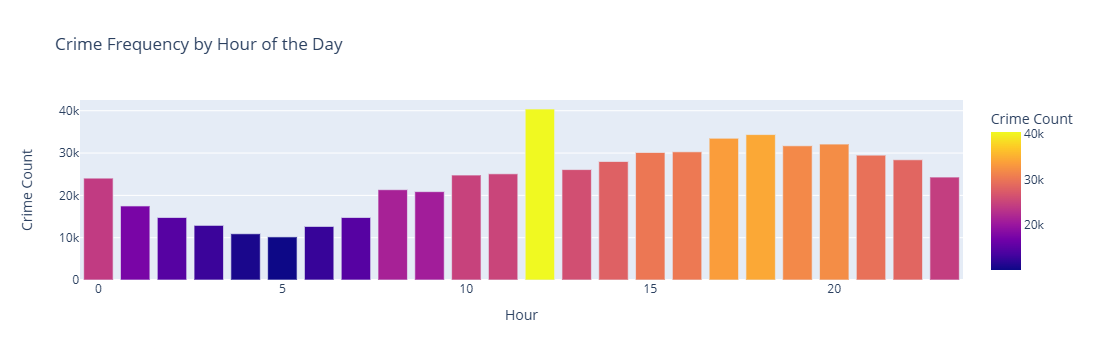

In [10]:
# --- 3. Time of Day When Crimes Occur ---
df['Hour'] = df['TIME OCC'].astype(str).str.zfill(4).str[:2].astype(int)
hourly_trend = df['Hour'].value_counts().sort_index().reset_index()
hourly_trend.columns = ['Hour', 'Crime Count']
fig3 = px.bar(hourly_trend, x='Hour', y='Crime Count', color='Crime Count',
              title='Crime Frequency by Hour of the Day')
fig3.show()

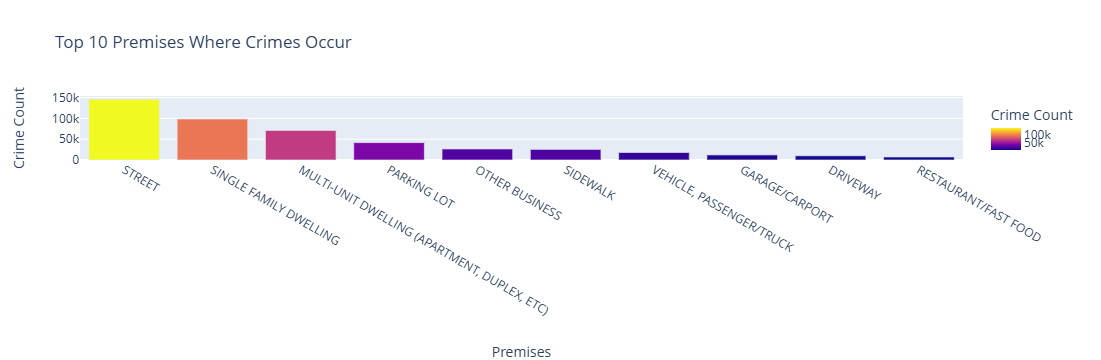

In [11]:
# --- 4. Most Common Premises for Crime ---
premises = df['Premis Desc'].value_counts().nlargest(10).reset_index()
premises.columns = ['Premises', 'Crime Count']
fig4 = px.bar(premises, x='Premises', y='Crime Count', color='Crime Count',
              title='Top 10 Premises Where Crimes Occur')
fig4.show()

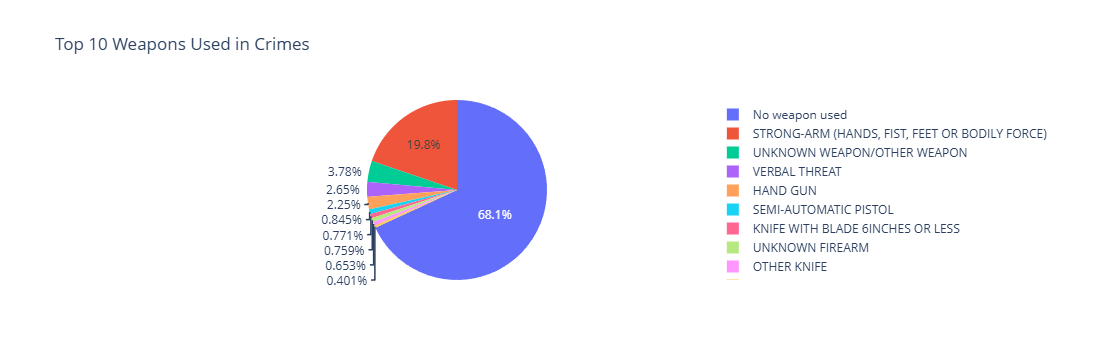

In [12]:
# --- 5. Weapon Usage Analysis ---
weapon_usage = df['Weapon Desc'].value_counts().nlargest(10).reset_index()
weapon_usage.columns = ['Weapon', 'Count']
fig5 = px.pie(weapon_usage, names='Weapon', values='Count', 
              title='Top 10 Weapons Used in Crimes')
fig5.show()

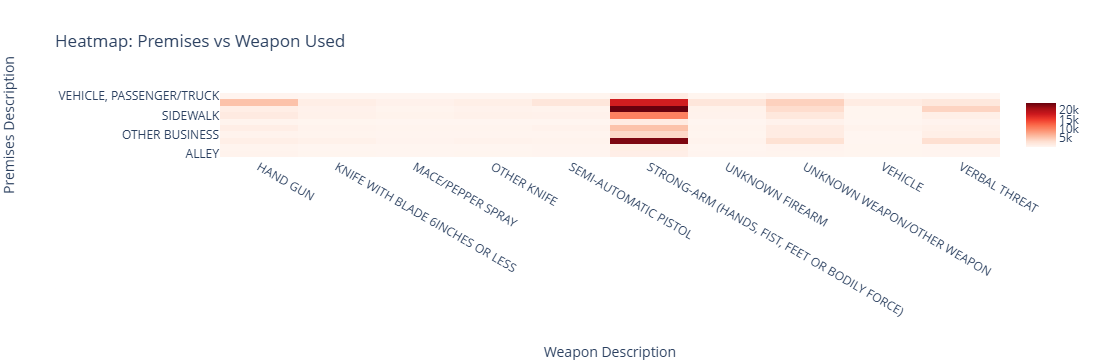

In [13]:
#---6. premises vs weapons used by type---
# Filter out rows where weapons were used (excluding 'No weapon used')
weapon_df = df[df['Weapon Desc'] != 'No weapon used']

# Group by Premises and Weapon Description
weapon_premise = weapon_df.groupby(['Premis Desc', 'Weapon Desc']).size().reset_index(name='Count')

# Optional: Limit to Top 10 Premises and Top 10 Weapons for clarity
top_premises = weapon_premise.groupby('Premis Desc')['Count'].sum().nlargest(10).index
top_weapons = weapon_premise.groupby('Weapon Desc')['Count'].sum().nlargest(10).index
filtered = weapon_premise[weapon_premise['Premis Desc'].isin(top_premises) & 
                          weapon_premise['Weapon Desc'].isin(top_weapons)]

# Pivot for heatmap
pivot = filtered.pivot(index='Premis Desc', columns='Weapon Desc', values='Count').fillna(0)

# Heatmap using plotly
import plotly.graph_objects as go

fig = go.Figure(data=go.Heatmap(
    z=pivot.values,
    x=pivot.columns,
    y=pivot.index,
    colorscale='Reds',
    hoverongaps=False
))

fig.update_layout(
    title='Heatmap: Premises vs Weapon Used',
    xaxis_title='Weapon Description',
    yaxis_title='Premises Description'
)

fig.show()
